In [1]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter
import random
from tqdm import tqdm
import unicodedata
import pickle

from torch.utils.data import Dataset, DataLoader, random_split
import torch
import torch.nn as nn
import torch.nn.functional as F

from nltk.translate.bleu_score import sentence_bleu

## 1. Explore and clean the dataset

In [2]:
path = "C:\\Users\\Chiara\\Desktop\\LEARN\\datasets\\fra-eng\\fra.txt"

data = pd.read_csv(path, sep="\t", header=None, names=["english", "french", "metadata"], usecols=[0,1])

In [3]:
data

,english,french
0,Go.,Va !
1,Go.,Marche.
2,Go.,En route !
3,Go.,Bouge !
4,Hi.,Salut !
...,...,...
240516,Death is something that we're often discourage...,La mort est une chose qu'on nous décourage sou...
240517,Since there are usually multiple websites on a...,Puisqu'il y a de multiples sites web sur chaqu...
240518,If someone who doesn't know your background sa...,Si quelqu'un qui ne connaît pas vos antécédent...
240519,It may be impossible to get a completely error...,Il est peut-être impossible d'obtenir un Corpu...


In [4]:
# Check null values

data.isnull().sum()

english    0
french     0
dtype: int64

In [5]:
# Remove duplicates, if they exist

data = data.drop_duplicates()
len(data)

240521

In [6]:
# Cleaning the text

def clean(text):

    text = text.lower()
    text = unicodedata.normalize("NFC", text)
    
    text = re.sub(r"([.!?])", r" \1", text)  # separation of punctuation
    text = re.sub(r"[^a-zA-ZÀ-ÿ.!?]+", " ", text)  # remove special characters, keep accents!
    text = re.sub(r"\s+", " ", text)  # remove multiple spaces

    return text.strip()

In [7]:
data["english"] = data["english"].apply(clean)
data["french"] = data["french"].apply(clean)

In [8]:
data.head()

,english,french
0,go .,va !
1,go .,marche .
2,go .,en route !
3,go .,bouge !
4,hi .,salut !


In [9]:
# Study of the sequences length

data["len_en"] = data["english"].apply(lambda x: len(x.split()))
data["len_fr"] = data["french"].apply(lambda x: len(x.split()))

count    240521.000000
mean          7.468051
std           2.567480
min           2.000000
25%           6.000000
50%           7.000000
75%           9.000000
max          66.000000
Name: len_en, dtype: float64


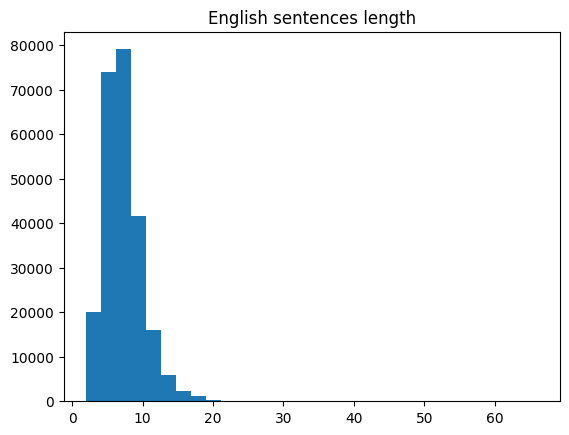

In [10]:
# Length distribution

plt.hist(data["len_en"], bins=30)
print(data["len_en"].describe())
plt.title("English sentences length")
plt.show()

count    240521.000000
mean          8.115379
std           2.989584
min           2.000000
25%           6.000000
50%           8.000000
75%          10.000000
max          69.000000
Name: len_fr, dtype: float64


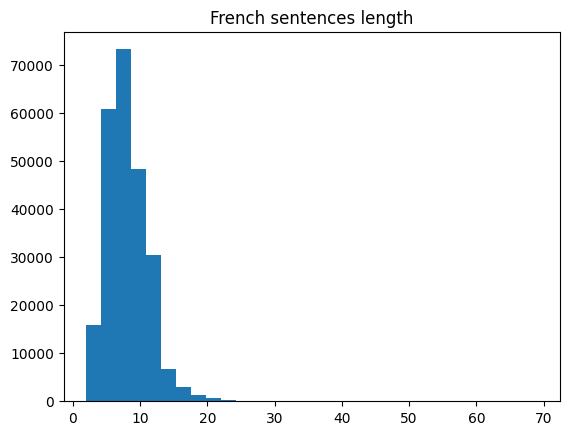

In [11]:
plt.hist(data["len_fr"], bins=30)
print(data["len_fr"].describe())
plt.title("French sentences length")
plt.show()

I can choose a sequence length of 10.

In [12]:
max_len = 10

In [13]:
# Filter dataset

data = data[(data["len_en"] <= max_len) & (data["len_fr"] <= max_len)]
len(data)

194013

By making this reduction, the training will be faster. I can reduce even more.

In [14]:
# Random sample

data = data.sample(50000, random_state=42)

In [15]:
len(data)

50000

In [16]:
# Convert into list of couples

pairs = list(zip(data["english"], data["french"]))
pairs = [(str(en), str(fr)) for en, fr in pairs]

In [17]:
pairs[:5]

[('you should all take a break .', 'vous devriez tous faire une pause .'),
 ('i m not old enough .', 'je ne suis point assez âgée .'),
 ('tom ran as fast as he was able to .',
  'tom a couru aussi vite qu il a pu .'),
 ('how many people have applied for that job ?',
  'combien de personnes ont postulé pour cet emploi ?'),
 ('this was my grandfather s watch .',
  'c était la montre de mon grand père .')]

## 2. Build vocabulary

In [18]:
# Special tokens

PAD_TOKEN = "<PAD>"
SOS_TOKEN = "<SOS>"
EOS_TOKEN = "<EOS>"
UNK_TOKEN = "<UNK>"

In [19]:
# Class vocabulary

class Vocabulary:

    def __init__(self):

        self.word2idx = {
            "<PAD>":0,
            "<SOS>":1,
            "<EOS>":2,
            "<UNK>":3
        }

        self.idx2word = {v:k for k,v in self.word2idx.items()}
        self.word_count = Counter()
        self.n_words = 4

    # Count words
    def add_sentence(self, sentence):

        for word in sentence.split():
            self.word_count[word] += 1

    # Add words to the vocabulary
    def build_vocab(self, min_freq=2):

        for word, count in self.word_count.items():
            if count >= min_freq and word not in self.word2idx:

                idx = self.n_words

                self.word2idx[word] = idx
                self.idx2word[idx] = word

                self.n_words += 1

    # Transform sentence into numbers
    def sentence_to_indices(self, sentence):

        tokens = sentence.split()
        indices = [self.word2idx.get(word, self.word2idx["<UNK>"]) for word in tokens]
        indices.append(self.word2idx["<EOS>"])

        return indices

In [20]:
# Create the french and english vocabularies

src_vocab = Vocabulary()
tgt_vocab = Vocabulary()

for en, fr in pairs:
    src_vocab.add_sentence(en)
    tgt_vocab.add_sentence(fr)

src_vocab.build_vocab()
tgt_vocab.build_vocab()

In [21]:
# Check dimensions

print("English vocabulary size: ", src_vocab.n_words)
print("French vocabulary size: ", tgt_vocab.n_words)

English vocabulary size:  5519
French vocabulary size:  7779


In [22]:
# Check

check = pairs[5]
check

('tom lives in a camper .', 'tom habite dans un camping car .')

In [23]:
src_vocab.sentence_to_indices(check[0])

[16, 38, 39, 8, 3, 10, 2]

In [24]:
tgt_vocab.sentence_to_indices(check[1])

[17, 41, 42, 43, 3, 44, 10, 2]

## 3. Preprocessing

In [25]:
# Padding function

def pad_sequence(seq, max_len, pad_value=0):

    seq = seq[:max_len]
    padding = [pad_value] * (max_len - len(seq))

    return seq + padding

In [26]:
# Create dataset torch

class TranslationDataset(Dataset):

    def __init__(self, pairs, src_vocab, tgt_vocab, max_len=max_len):

        self.pairs = pairs
        self.src_vocab = src_vocab
        self.tgt_vocab = tgt_vocab
        self.max_len = max_len

    # Length dataset
    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):

        src_sentence, tgt_sentence = self.pairs[idx] 

        # Convert sentences into indices
        src_indices = self.src_vocab.sentence_to_indices(src_sentence)
        tgt_indices = self.tgt_vocab.sentence_to_indices(tgt_sentence)

        # Padding
        src_indices = pad_sequence(src_indices, self.max_len)
        tgt_indices = pad_sequence(tgt_indices, self.max_len)

        # Convert into tensors
        src_tensor = torch.tensor(src_indices)
        tgt_tensor = torch.tensor(tgt_indices)

        return src_tensor, tgt_tensor

In [27]:
dataset = TranslationDataset(pairs, src_vocab, tgt_vocab, max_len=max_len)

In [28]:
dataset.pairs[:5]

[('you should all take a break .', 'vous devriez tous faire une pause .'),
 ('i m not old enough .', 'je ne suis point assez âgée .'),
 ('tom ran as fast as he was able to .',
  'tom a couru aussi vite qu il a pu .'),
 ('how many people have applied for that job ?',
  'combien de personnes ont postulé pour cet emploi ?'),
 ('this was my grandfather s watch .',
  'c était la montre de mon grand père .')]

In [29]:
# Split train and validation

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

In [30]:
# dataloader

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)

## 4. Model

### 4.1. Encoder

In [31]:
# Encoder class

class Encoder(nn.Module):

    def __init__(self, input_dim, embed_dim, hidden_dim, num_layers):

        super().__init__()

        self.embedding = nn.Embedding(input_dim, embed_dim)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers=num_layers, batch_first=True)

    def forward(self, src):

        embedded = self.embedding(src)
        outputs, (hidden, cell) = self.lstm(embedded)

        return outputs, hidden, cell

In [32]:
# Parameters encoder

INPUT_DIM = src_vocab.n_words
EMBED_DIM = 300
HIDDEN_DIM = 768

### 4.2. Decoder

In [33]:
# Attention class

class Attention(nn.Module):

    def __init__(self, hidden_dim):

        super().__init__()

        self.attn = nn.Linear(hidden_dim * 2, hidden_dim)
        self.v = nn.Linear(hidden_dim, 1, bias=False)

    def forward(self, hidden, encoder_outputs):

        batch_size = encoder_outputs.shape[0]
        src_len = encoder_outputs.shape[1]

        hidden = hidden[-1].unsqueeze(1).repeat(1, src_len, 1)

        energy = torch.tanh(self.attn(torch.cat((hidden, encoder_outputs), dim=2)))

        attention = self.v(energy).squeeze(2)

        return torch.softmax(attention, dim=1)

In [34]:
# Decoder class

class Decoder(nn.Module):

    def __init__(self, output_dim, embed_dim, hidden_dim, attention):

        super().__init__()

        self.output_dim = output_dim
        self.attention = attention

        self.embedding = nn.Embedding(output_dim, embed_dim)

        self.lstm = nn.LSTM(
            embed_dim + hidden_dim,
            hidden_dim,
            batch_first=True,
            num_layers = 2
        )

        self.fc = nn.Linear(hidden_dim * 2, output_dim)

    def forward(self, input_token, hidden, cell, encoder_outputs):

        input_token = input_token.unsqueeze(1)

        embedded = self.embedding(input_token)

        attn_weights = self.attention(hidden, encoder_outputs)
        attn_weights = attn_weights.unsqueeze(1)

        context = torch.bmm(attn_weights, encoder_outputs)

        lstm_input = torch.cat((embedded, context), dim=2)

        output, (hidden, cell) = self.lstm(lstm_input, (hidden, cell))

        prediction = self.fc(torch.cat((output.squeeze(1), context.squeeze(1)), dim=1))

        return prediction, hidden, cell

In [35]:
# Parameters decoder

OUTPUT_DIM = tgt_vocab.n_words

### 4.3. Seq2Seq

In [36]:
# Seq2Seq class

class Seq2Seq(nn.Module):

    def __init__(self, encoder, decoder, device):

        super().__init__()

        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(self, src, tgt, teacher_forcing_ratio=0.5):

        batch_size = src.shape[0]
        tgt_len = tgt.shape[1]
        tgt_vocab_size = self.decoder.fc.out_features

        outputs = torch.zeros(batch_size, tgt_len, tgt_vocab_size).to(self.device)

        encoder_outputs, hidden, cell = self.encoder(src)

        input_token = tgt[:,0]

        for t in range(1, tgt_len):

            prediction, hidden, cell = self.decoder(input_token, hidden, cell, encoder_outputs)
            outputs[:,t] = prediction
            teacher_force = random.random() < teacher_forcing_ratio
            top1 = prediction.argmax(1)
            input_token = tgt[:,t] if teacher_force else top1

        return outputs

In [37]:
attention = Attention(768)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
encoder = Encoder(src_vocab.n_words, 300, 768, num_layers=2)
decoder = Decoder(tgt_vocab.n_words, 300, 768, attention)

model = Seq2Seq(encoder, decoder, device).to(device)

## 5. Training

In [38]:
# Some premises for training

PAD_IDX = tgt_vocab.word2idx["<PAD>"]
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [39]:
# Training function

def train(model, loader, optimizer, criterion, device):

    model.train()
    epoch_loss = 0

    progress_bar = tqdm(loader, desc="Training", leave=False)

    for src, tgt in progress_bar:

        src = src.to(device)
        tgt = tgt.to(device)

        optimizer.zero_grad()

        output = model(src, tgt)

        output_dim = output.shape[-1]

        output = output[:,1:].reshape(-1, output_dim)
        tgt = tgt[:,1:].reshape(-1)

        loss = criterion(output, tgt)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1)
        optimizer.step()

        epoch_loss += loss.item()

        progress_bar.set_postfix(loss=loss.item())

    return epoch_loss / len(loader)

In [40]:
# Function to evaluate on the validation set

def evaluate(model, loader, criterion, device):

    model.eval()

    epoch_loss = 0

    with torch.no_grad():

        for src, tgt in loader:

            src = src.to(device)
            tgt = tgt.to(device)

            output = model(src, tgt, teacher_forcing_ratio=0)

            output_dim = output.shape[-1]

            output = output[:,1:].reshape(-1, output_dim)
            tgt = tgt[:,1:].reshape(-1)

            loss = criterion(output, tgt)

            epoch_loss += loss.item()

    return epoch_loss / len(loader)

In [41]:
# Train

N_EPOCHS = 20

best_val_loss = float("inf")
patience = 3
counter = 0

for epoch in range(N_EPOCHS):
    train_loss = train(model, train_loader, optimizer, criterion, device)
    val_loss = evaluate(model, val_loader, criterion, device)

    print(f"Epoch {epoch+1}")
    print(f"Train loss: {train_loss}")
    print(f"Val loss: {val_loss}")

    # Save the best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0
        torch.save(model.state_dict(), "best_model.pt")
        print("Model saved")
    else:
        counter += 1

    if counter >= patience:
        print("Early stopping")
        break

Epoch 1
Train loss: 3.7540845880508424
Val loss: 3.281953754516455
Model saved


Epoch 2
Train loss: 2.1819773847579955
Val loss: 2.6654679478166963
Model saved


Epoch 3
Train loss: 1.3800581983566285
Val loss: 2.555962767083043
Model saved


Epoch 4
Train loss: 0.9031763778686523
Val loss: 2.667929624216244


Epoch 5
Train loss: 0.622675830578804
Val loss: 2.7424739686825785


Epoch 6
Train loss: 0.45947024074792864
Val loss: 2.8999390503088125
Early stopping


In [42]:
# Save dictionaries

with open("src_vocab.pkl", "wb") as f:
    pickle.dump(src_vocab, f)

with open("tgt_vocab.pkl", "wb") as f:
    pickle.dump(tgt_vocab, f)

## 6. Translation 

In [43]:
model.load_state_dict(torch.load("best_model.pt"))

C:\Users\Chiara\AppData\Local\Temp\ipykernel_19812\349716640.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_model.pt"))


<All keys matched successfully>

In [44]:
# Beam search

def translate_beam_search(sentence, src_vocab, tgt_vocab, model, device,
                          beam_size=3, max_len=20):

    model.eval()

    tokens = sentence.lower().split()

    src_indices = [
        src_vocab.word2idx.get(t, src_vocab.word2idx["<UNK>"])
        for t in tokens
    ]

    src_indices.append(src_vocab.word2idx["<EOS>"])

    src_tensor = torch.tensor(src_indices).unsqueeze(0).to(device)

    with torch.no_grad():
        encoder_outputs, hidden, cell = model.encoder(src_tensor)

    beams = [([tgt_vocab.word2idx["<SOS>"]], 0.0, hidden, cell)]

    for _ in range(max_len):

        new_beams = []

        for seq, score, hidden, cell in beams:

            input_token = torch.tensor([seq[-1]]).to(device)

            if seq[-1] == tgt_vocab.word2idx["<EOS>"]:
                new_beams.append((seq, score, hidden, cell))
                continue

            with torch.no_grad():

                prediction, hidden_new, cell_new = model.decoder(
                    input_token,
                    hidden,
                    cell,
                    encoder_outputs
                )

            probs = F.log_softmax(prediction, dim=1)

            topk_probs, topk_indices = probs.topk(beam_size)

            for i in range(beam_size):

                token = topk_indices[0][i].item()
                new_score = score + topk_probs[0][i].item()

                new_seq = seq + [token]

                new_beams.append(
                    (new_seq, new_score, hidden_new, cell_new)
                )

        beams = sorted(new_beams, key=lambda x: x[1], reverse=True)[:beam_size]

    best_seq = beams[0][0]

    words = [
        tgt_vocab.idx2word[idx]
        for idx in best_seq
        if idx not in (
            tgt_vocab.word2idx["<SOS>"],
            tgt_vocab.word2idx["<EOS>"]
        )
    ]

    return " ".join(words)

In [50]:
# Test

sentences_to_test = ["My name is Chiara", "I like this", "it' early in the morning", "he was sick yesterday"]

for sentence in sentences_to_test:
    translation = translate_beam_search(sentence,src_vocab,tgt_vocab,model,device,beam_size=3)

    print(f"\nOriginal: {sentence}")
    print(f"Translation:{translation}")


Original: My name is Chiara
Translation:mon nom est <UNK> .

Original: I like this
Translation:j aime ça .

Original: it' early in the morning
Translation:des <UNK> <UNK> matin .

Original: he was sick yesterday
Translation:il était malade hier .


The model can sometimes capture the maening but lacks correct grammar. In general, translations are not very accurate; this might depend on the limited dataset and the model capacity.

## 7. Model evaluation: Bleu score

In [46]:
# Compute Bleu score function

def compute_bleu(pairs, model, src_vocab, tgt_vocab, device):

    scores = []

    for src, tgt in pairs:

        prediction = translate_beam_search(
            src,
            src_vocab,
            tgt_vocab,
            model,
            device, 
            beam_size=3
        )

        reference = tgt.split()
        candidate = prediction.split()

        score = sentence_bleu([reference], candidate)

        scores.append(score)

    return sum(scores) / len(scores)

In [47]:
sample_pairs = pairs[:100]

bleu = compute_bleu(
    sample_pairs,
    model,
    src_vocab,
    tgt_vocab,
    device
)

print("BLEU score:", bleu)

C:\Users\Chiara\anaconda3\envs\cv\lib\site-packages\nltk\translate\bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 4-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)
C:\Users\Chiara\anaconda3\envs\cv\lib\site-packages\nltk\translate\bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 3-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)
C:\Users\Chiara\anaconda3\envs\cv\lib\site-packages\nltk\translate\bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 2-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use S

BLEU score: 0.16450291652626306


This value shows that the model captures something, but its capacity is still very limited. Why?
* Limited dataset for training
* Sentences cut at length 10
* Limited vocabulary

## 8. Attention visualization

What the decoder is looking at a specific input word? I build an heatmap where:
* the horizontal axis is the input word (english)
* the vertical axis is the generated word (french)

In [51]:
def translate_with_attention(sentence, src_vocab, tgt_vocab, model, device, max_len=20):

    model.eval()

    tokens = sentence.lower().split()

    src_indices = [src_vocab.word2idx.get(t, src_vocab.word2idx["<UNK>"])for t in tokens]
    src_indices.append(src_vocab.word2idx["<EOS>"])

    src_tensor = torch.tensor(src_indices).unsqueeze(0).to(device)

    with torch.no_grad():
        encoder_outputs, hidden, cell = model.encoder(src_tensor)

    input_token = torch.tensor([tgt_vocab.word2idx["<SOS>"]]).to(device)

    outputs = []
    attentions = []

    for _ in range(max_len):

        with torch.no_grad():

            attn_weights = model.decoder.attention(hidden, encoder_outputs)
            prediction, hidden, cell = model.decoder(input_token, hidden, cell, encoder_outputs)

        attentions.append(attn_weights.cpu().numpy())

        top1 = prediction.argmax(1).item()

        if top1 == tgt_vocab.word2idx["<EOS>"]:
            break

        outputs.append(top1)

        input_token = torch.tensor([top1]).to(device)

    translated_tokens = [tgt_vocab.idx2word[idx] for idx in outputs]

    return translated_tokens, tokens, attentions

In [59]:
# Test on a sentence

sentence = "I like dogs"

translation, input_tokens, attentions = translate_with_attention(sentence, src_vocab, tgt_vocab, model, device)

print("Input:", input_tokens)
print("Output:", translation)

Input: ['i', 'like', 'dogs']
Output: ['j', 'aime', 'les', 'chiens', '.']


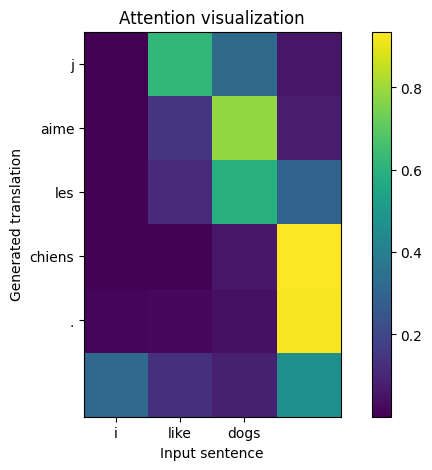

In [60]:
# Create matrix and visualization

attention_matrix = np.vstack(attentions)

plt.figure(figsize=(8,5))

plt.imshow(attention_matrix, cmap="viridis")

plt.xticks(range(len(input_tokens)), input_tokens)
plt.yticks(range(len(translation)), translation)
plt.xlabel("Input sentence")
plt.ylabel("Generated translation")
plt.title("Attention visualization")
plt.colorbar()

plt.show()

Analysis:
* The model didn't perfectly learn the match I = Je
* It didn't learn well the match between french and english verbs